In [219]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [255]:
df = pd.read_csv("Property.csv",delimiter=";")
df.head(5)


,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN


In [221]:
# df['area'].unique().tolist()

arr=[]

# df.columns.tolist()

skip=[
'property_id',
 'location_id',
 'page_url',
 'price']


for col in df.columns:
    if col in skip:
        continue
    print(f"Column: {col}")
    print(df[col].unique().tolist())
    print("-"*40)

Column: property_type
['House', 'Flat', 'Lower Portion', 'Penthouse', 'Upper Portion', 'Farm House', 'Room']
----------------------------------------
Column: location
['Model Town', 'Multan Road', 'Eden', 'Gulberg', 'Allama Iqbal Town', 'Military Accounts Housing Society', 'EME Society', 'Izmir Town', 'Upper Mall', 'Park View Villas', 'Cavalry Ground', 'Bahria Town', 'Askari', 'Bedian Road', 'Agrics Town', 'Chaman Park', 'Chungi Amar Sadhu', 'GOR', 'Karim Park', 'Cantt', 'Valencia Housing Society', 'Gulshan-e-Ravi', 'Al-Raheem Garden', 'Mateen Avenue', 'Paragon City', 'IEP Engineers Town', 'Architects Engineers Housing Society', 'DHA Defence', 'Samanabad', 'Mozang', 'Garden Town', 'Sultan Pura', 'Sabzazar Scheme', 'T & T Aabpara Housing Society', 'Al Faisal Town', 'Canal Garden', 'Muslim Nagar Housing Scheme', 'Johar Town', 'Tricon Village', 'PCSIR Housing Scheme', 'Pak Arab Housing Society', 'Green Fort', 'Wapda Town', 'State Life Housing Society', 'Wahdat Road', 'DHA 11 Rahbar', 'She

In [222]:
df.tail(5)
df.shape
df.columns
df.info()
df.describe()
df.describe(include="string")

<class 'pandas.DataFrame'>
RangeIndex: 191393 entries, 0 to 191392
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    191393 non-null  int64  
 1   location_id    191393 non-null  int64  
 2   page_url       191393 non-null  str    
 3   property_type  191393 non-null  str    
 4   price          191393 non-null  int64  
 5   location       191393 non-null  str    
 6   city           191393 non-null  str    
 7   province_name  191393 non-null  str    
 8   latitude       191393 non-null  float64
 9   longitude      191393 non-null  float64
 10  baths          191393 non-null  int64  
 11  area           191393 non-null  str    
 12  purpose        191393 non-null  str    
 13  bedrooms       191393 non-null  int64  
 14  date_added     191393 non-null  str    
 15  agency         144014 non-null  str    
 16  agent          144013 non-null  str    
dtypes: float64(2), int64(5), str(10)
memory 

,page_url,property_type,location,city,province_name,area,purpose,date_added,agency,agent
count,191393,191393,191393,191393,191393,191393,191393,191393,144014,144013
unique,191393,7,1536,5,3,352,2,148,5923,11352
top,https://www.zameen.com/Property/lahore_model_t...,House,DHA Defence,Karachi,Punjab,1 Kanal,For Sale,07-03-2019,Mash Allah Estate & Builders,Azam Ali
freq,1,118915,26161,60484,90714,25452,127018,10400,821,797


In [223]:
# df.to_excel('f1.xlsx', index=False)  # index=False avoids writing row numbers

Phase 2: Data Cleaning and Preparation

In [256]:
df = df.drop(columns=["page_url",'location_id'])

df.head()

,property_id,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN


In [257]:
# df.isnull().sum()

# df["agency"].replace("",np.nan,inplace = True)


df['agency'] = df['agency'].fillna("Unknown")

df['agent'] = df['agent'].fillna("Unknown")

df['agency']

0          Real Biz International
1                     Khan Estate
2                 Shahum Estate 2
3                         Unknown
4                         Unknown
                   ...           
191388             Property World
191389             Property World
191390           Azaan Associates
191391    New National Properties
191392               Select Homes
Name: agency, Length: 191393, dtype: str

In [258]:
df['area_in_marla'] = df['area'].str.extract(r'(\d+\.?\d*)').astype(float)


df['area_in_marla'] = np.where(df['area'].str.contains('kanal',case=False,na=False),
         df['area_in_marla']*20,
         df['area_in_marla'])

In [227]:
df.columns

Index(['property_id', 'property_type', 'price', 'location', 'city',
       'province_name', 'latitude', 'longitude', 'baths', 'area', 'purpose',
       'bedrooms', 'date_added', 'agency', 'agent', 'area_in_marla'],
      dtype='str')

In [259]:
df.loc[df['area_in_marla'] == 0 ].count()


property_id      16
property_type    16
price            16
location         16
city             16
province_name    16
latitude         16
longitude        16
baths            16
area             16
purpose          16
bedrooms         16
date_added       16
agency           16
agent            16
area_in_marla    16
dtype: int64

In [229]:
df

,property_id,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,area_in_marla
0,347795,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan,120.0
1,482892,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B,20.0
2,555962,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar",9.0
3,562843,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,Unknown,Unknown,20.0
4,686990,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,Unknown,Unknown,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191388,17468383,Upper Portion,70000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,3,07-24-2019,Property World,Zafran,12.4
191389,17468384,Upper Portion,40000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,2,07-24-2019,Property World,Zafran,12.4
191390,17468482,House,160000,G-10,Islamabad,Islamabad Capital,33.676104,73.013842,6,1 Kanal,For Rent,6,07-24-2019,Azaan Associates,Usman Rehman,20.0
191391,17468586,Flat,25000,DHA Defence,Islamabad,Islamabad Capital,33.527944,73.161392,2,2.7 Marla,For Rent,2,07-24-2019,New National Properties,TALHA MIAN AHMAD,2.7


In [260]:
# df[df['area_in_marla'] == 0][['area','area_in_marla','property_id', 'property_type', 'price', 'location', 'city','province_name', 'latitude', 'longitude', 'baths', 'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent', 'area_in_marla']].head()

# df.loc[df['area'] == '0 Marla']

df = df[df['area'] != '0 Marla']

##Numeric & Categorical COlumns

In [261]:
Numeric_cols  = df.select_dtypes(include=['int64','float']).columns
print('Numerical Columns',Numeric_cols)


Numerical Columns Index(['property_id', 'price', 'latitude', 'longitude', 'baths', 'bedrooms',
       'area_in_marla'],
      dtype='str')


In [262]:

categorical_cols  = df.select_dtypes(include=  ['object','category','string']).columns
print('categorical_cols Columns',categorical_cols)

categorical_cols Columns Index(['property_type', 'location', 'city', 'province_name', 'area', 'purpose',
       'date_added', 'agency', 'agent'],
      dtype='str')


In [263]:
print(f'Numeric Columns:\n {df[Numeric_cols].describe()}')

Numeric Columns:
         property_id         price       latitude      longitude  \
count  1.913770e+05  1.913770e+05  191377.000000  191377.000000   
mean   1.573160e+07  1.644728e+07      30.104401      71.572865   
std    2.215296e+06  3.416535e+07       3.645979       3.080525   
min    8.657500e+04  0.000000e+00      11.052446      25.906027   
25%    1.511858e+07  8.000000e+04      24.972287      67.152597   
50%    1.676379e+07  7.300000e+06      31.463335      73.077743   
75%    1.715282e+07  1.800000e+07      33.550869      74.228218   
max    1.769386e+07  2.000000e+09      73.184088      80.161430   

               baths       bedrooms  area_in_marla  
count  191377.000000  191377.000000  191377.000000  
mean        2.865982       3.171562      12.244329  
std         2.435368       1.952414      90.278590  
min         0.000000       0.000000       0.100000  
25%         0.000000       2.000000       4.900000  
50%         3.000000       3.000000       7.600000  
75%    

In [234]:
print(f'\n Categorical Columns:\n {df[categorical_cols].describe()}')


 Categorical Columns:
        property_type     location     city province_name     area   purpose  \
count         191377       191377   191377        191377   191377    191377   
unique             7         1536        5             3      351         2   
top            House  DHA Defence  Karachi        Punjab  1 Kanal  For Sale   
freq          118903        26161    60483         90707    25452    127007   

        date_added   agency    agent  
count       191377   191377   191377  
unique         148     5924    11353  
top     07-03-2019  Unknown  Unknown  
freq         10399    47379    47380  


In [235]:
## Show all rows

# pd.set_option('display.max_rows', None)

In [236]:
# df.loc[df['price']>10000000].head()

In [237]:
# df['price'].sort_values(ascending=True,ignore_index=True)

In [238]:

# Numeric_cols  = df.select_dtypes(include=['int64','float'])
# print('Numerical Columns',Numeric_cols)

# categorical_cols  = df.select_dtypes(include = ['object','category'])
# print('categorical_cols Columns',categorical_cols)

In [239]:
df[['price','area_in_marla']].describe()

,price,area_in_marla
count,1.913770e+05,191377.000000
mean,1.644728e+07,12.244329
std,3.416535e+07,90.278590
min,0.000000e+00,0.100000
25%,8.000000e+04,4.900000
50%,7.300000e+06,7.600000
75%,1.800000e+07,12.000000
max,2.000000e+09,16000.000000


In [240]:
df[['price','area_in_marla']].head()

,price,area_in_marla
0,220000000,120.0
1,40000000,20.0
2,9500000,9.0
3,125000000,20.0
4,21000000,11.0


In [241]:
df.loc[df['area_in_marla']]

KeyError: '[7.5, 2.5, 9.7, 5.5, 8.2, 10.1, 4.3, 8.9, 3.2, 9.6, 9.8, 10.2, 11.4, 13.1, 4.8, 7.6, 5.4, 13.4, 13.2, 5.2, 1.3, 6.1, 9.1, 4.2, 10.6, 6.7, 11.2, 15.8, 12.2, 10.3, 3.7, 5.1, 8.8, 3.4, 2.9, 5.8, 3.6, 18.2, 11.8, 6.2, 3.3, 4.9, 4.7, 4.4, 18.4, 7.3, 11.7, 5.6, 8.1, 10.7, 2.8, 12.5, 5.3, 1.9, 2.2, 7.1, 7.8, 3.1, 1.5, 8.4, 17.8, 10.9, 3.8, 6.9, 6.6, 11.1, 4.1, 16.4, 9.3, 4.6, 2.7, 11.5, 1.1, 13.6, 0.9, 14.7, 14.2, 13.3, 11.6, 2.4, 3.5, 6.5, 15.2, 4.5, 10.8, 1.7, 6.4, 5.7, 1.8, 5.9, 8.7, 19.1, 1.2, 10.4, 15.9, 6.3, 13.8, 8.6, 15.3, 2.6, 6.8, 8.3, 7.9, 12.4, 1.6, 16.8, 3.9, 17.3, 12.6, 7.2, 8.5, 7.4, 16.2, 9.2, 13.5, 10.5, 12.1, 18.7, 9.5, 13.7, 0.4, 15.6, 15.1, 12.8, 14.3, 9.4, 2.1, 0.6, 0.8, 0.5, 1.4, 18.1, 17.2, 15.4, 17.7, 2.3, 14.4, 15.5, 12.3, 9.9, 14.8, 19.2, 0.3, 0.2, 16.3, 14.6, 11.3, 16.6, 17.5, 7.7, 16.7, 17.1, 17.6, 0.7, 12.7, 16.9, 18.6, 18.3, 12.9, 18.8, 13.9, 19.8, 14.5, 11.9, 19.7, 17.4, 14.1, 15.7, 16.5, 19.5, 19.6, 19.4, 0.1, 18.9, 17.9, 14.9, 18.5, 19.3, 19.9] not 

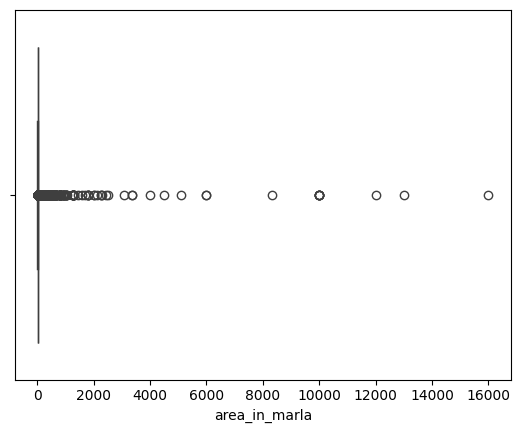

In [264]:
sns.boxplot(x=df['area_in_marla'])
plt.show()

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

outliers.head(100)


In [ ]:
# pd.set_option('display.max_columns', None)

In [ ]:
q1=df['price'].quantile(0.25)
q3=df['price'].quantile(0.75)

IQR =q3-q1
lower = q1-1.5*IQR
upper = q3+1.5*IQR
outliers = df[(df['price']<lower) | (df['price']>upper)]
print(outliers.head(1))

Removing invalid data

In [ ]:
# df['area_in_marla']
# df['price'] 

df.head(10)

In [ ]:
# df = df.dropna(subset=['area','price','bedrooms','baths','city'])

In [ ]:
df.head(5)

In [ ]:
df[df.isnull().sum(axis=1) > 5]

In [ ]:
# df[df[['area','price','bedrooms','baths','city']].isnull().any(axis=1)]
df[df[['area']].isnull()]

In [ ]:
df

In [ ]:
df

In [ ]:
df.head(10)

In [ ]:
# df['area'].isnull()#.head(100)

df.loc[df['area'].isnull()]

In [ ]:
df[df['area'].isna()]

In [ ]:
df['area'].unique().tolist()

##Phase 4: Exploratory Data Analysis (EDA)

A. Univariate Analysis (One Variable)

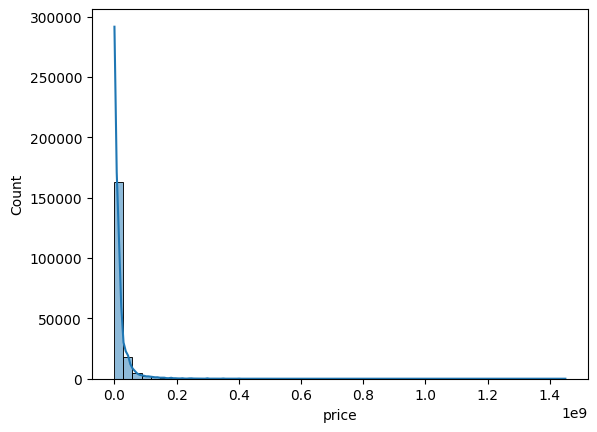

In [274]:
sns.histplot(df['price'],bins=50,kde=True)
plt.show()

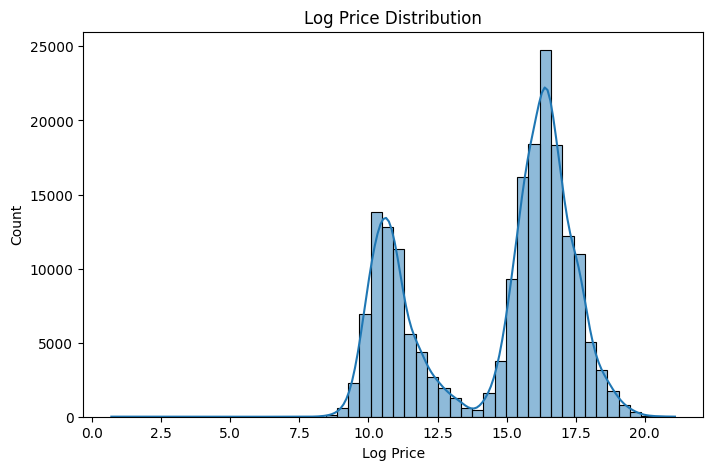

In [275]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['price']), bins=50, kde=True)

plt.title("Log Price Distribution")
plt.xlabel("Log Price")
plt.ylabel("Count")

plt.show()

In [277]:
df.columns

Index(['property_id', 'property_type', 'price', 'location', 'city',
       'province_name', 'latitude', 'longitude', 'baths', 'area', 'purpose',
       'bedrooms', 'date_added', 'agency', 'agent', 'area_in_marla'],
      dtype='str')

In [281]:
df.groupby('property_type')['property_id'].count()

property_type
Farm House          724
Flat              40156
House            118900
Lower Portion     11692
Penthouse           399
Room               1029
Upper Portion     18473
Name: property_id, dtype: int64

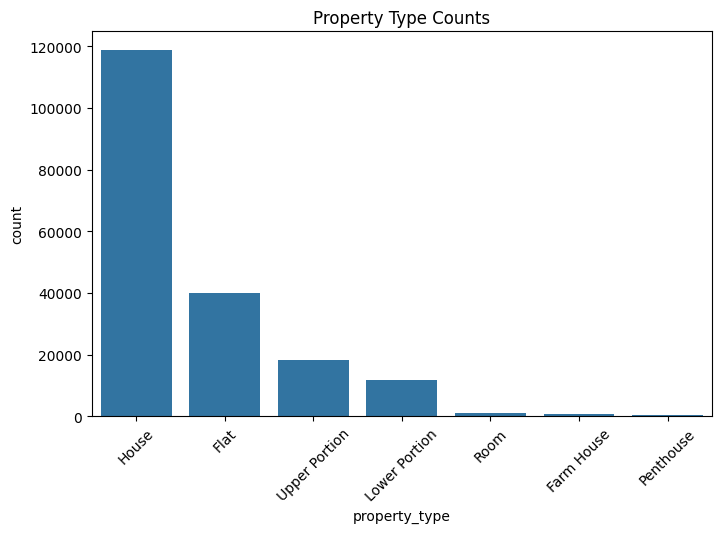

In [282]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='property_type', order=df['property_type'].value_counts().index)

plt.title("Property Type Counts")
plt.xticks(rotation=45)
plt.show()

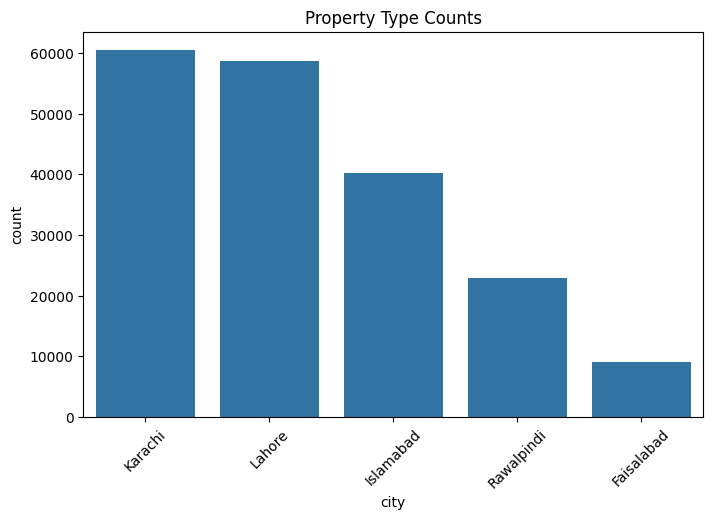

In [283]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='city', order=df['city'].value_counts().index)

plt.title("Property Type Counts")
plt.xticks(rotation=45)
plt.show()

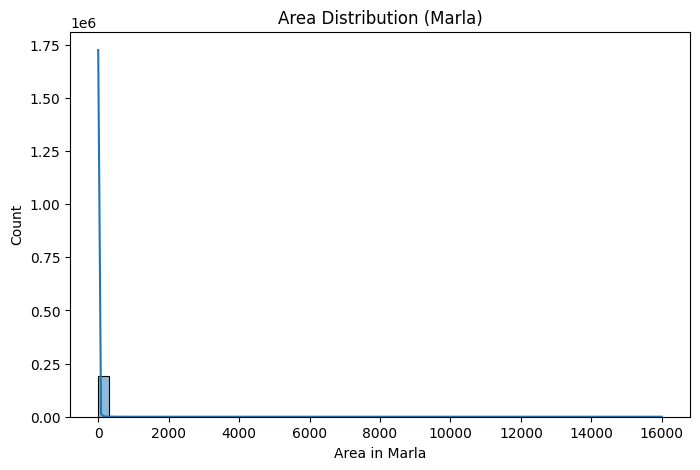

In [284]:
plt.figure(figsize=(8,5))

sns.histplot(df['area_in_marla'], bins=50, kde=True)

plt.title("Area Distribution (Marla)")
plt.xlabel("Area in Marla")

plt.show()

B. Bivariate Analysis (Two Variables)

In [314]:
top3 = ['Lahore', 'Karachi', 'Islamabad']
df_top = df[df['city'].isin(top3)]


In [317]:
df_top.groupby('city')['price'].median()

city
Islamabad      240000.0
Karachi       8500000.0
Lahore       11500000.0
Name: price, dtype: float64

In [318]:
top3 = ['Lahore', 'Karachi', 'Islamabad']
df_top = df[df['city'].isin(top3)]

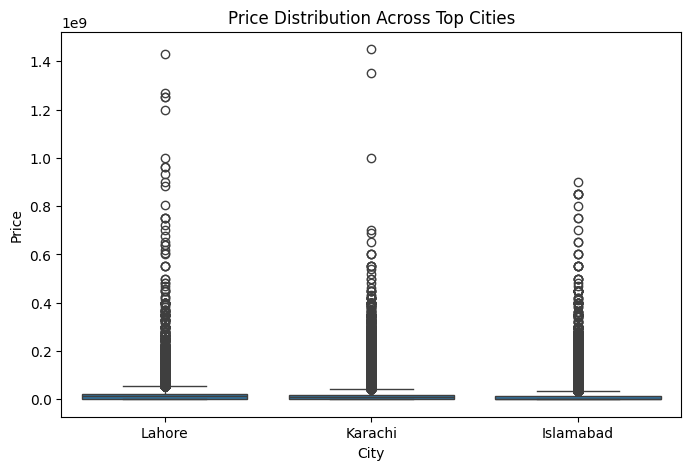

In [319]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_top, x='city', y='price')

plt.title("Price Distribution Across Top Cities")
plt.xlabel("City")
plt.ylabel("Price")

plt.show()

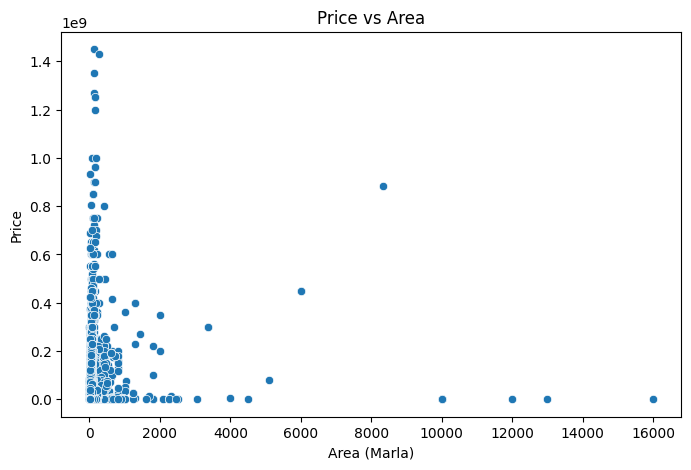

In [322]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='area_in_marla', y='price')

plt.title("Price vs Area")
plt.xlabel("Area (Marla)")
plt.ylabel("Price")

plt.show()

In [329]:
df['area_in_marla'].min()
df['area_in_marla'].max()

np.float64(16000.0)

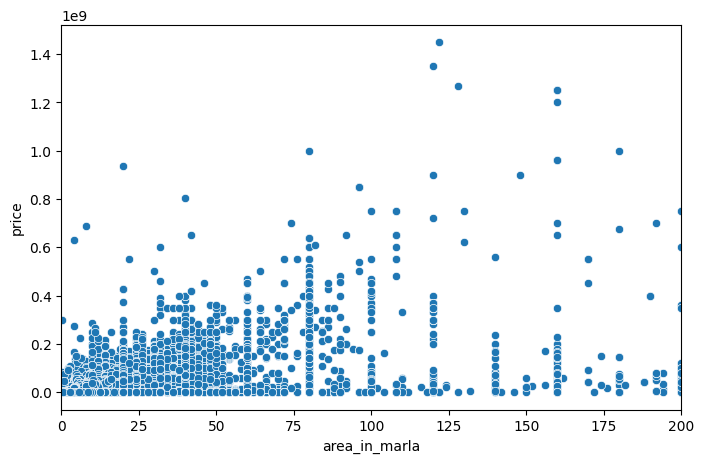

In [330]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='area_in_marla', y='price')
plt.xlim(0,200)
plt.show()

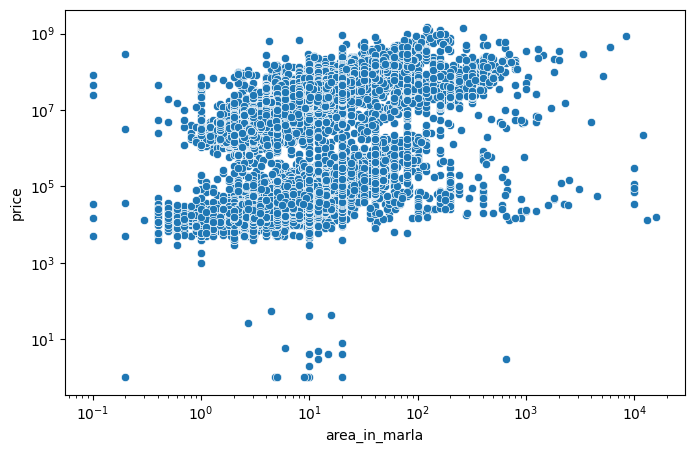

In [333]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='area_in_marla', y='price')
plt.xscale('log')
plt.yscale('log')
plt.show()

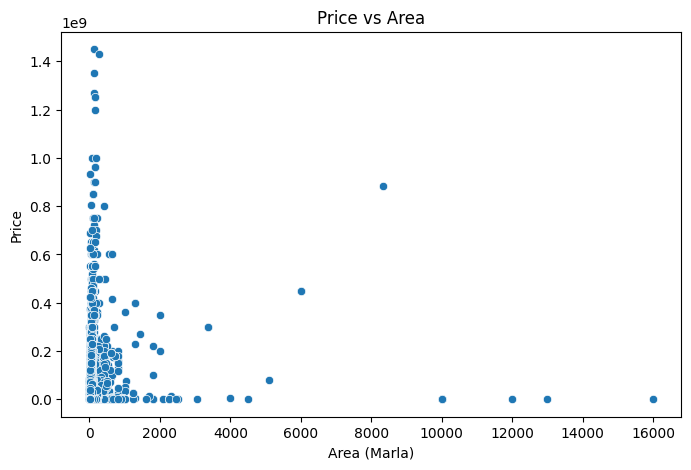

In [334]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='area_in_marla', y='price')

plt.title("Price vs Area")
plt.xlabel("Area (Marla)")
plt.ylabel("Price")

plt.show()

7. Bathrooms vs. Price: Do properties with more baths command a higher price? Visualize
this relationship.

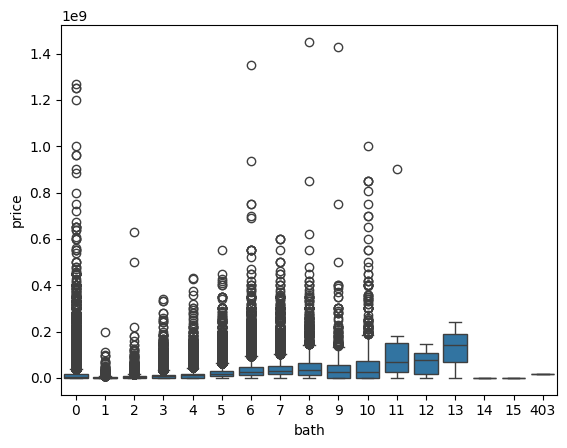

In [338]:
sns.boxplot(data=df,x='baths',y='price')
plt.xlabel('bath')
plt.ylabel('price')
plt.show()

In [ ]:
8. Date vs. Count: Extract the year from date_added. How has the number of listings
changed from year to year?

In [340]:

df['date_added'] = pd.to_datetime(df['date_added'])

In [341]:
df['Year'] = df['date_added'].dt.year

In [342]:
years_count = df['Year'].value_counts().sort_index()

In [347]:
df['Month'] = df['date_added'].dt.month

In [348]:
month_count = df['Month'].value_counts().sort_index()

In [349]:
month_count,years_count

(Month
 1      4800
 2      5440
 3      6414
 4      9641
 5     14130
 6     50563
 7     88054
 8      1871
 9      2509
 10     2706
 11     2589
 12     2656
 Name: count, dtype: int64,
 Year
 2018     12309
 2019    179064
 Name: count, dtype: int64)

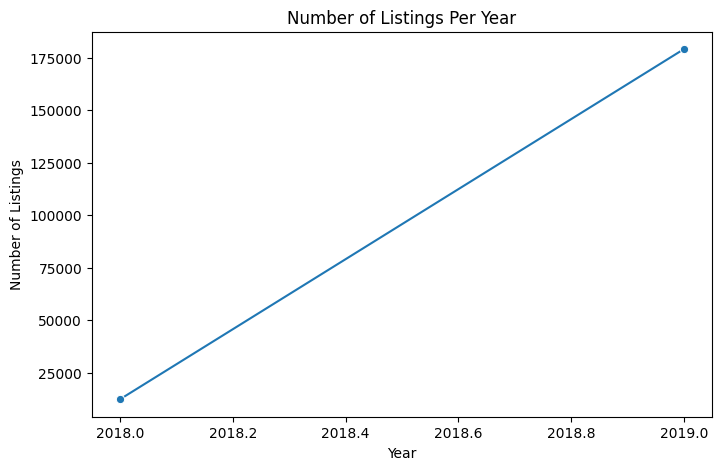

In [355]:
plt.figure(figsize=(8,5))

sns.lineplot(x=years_count.index, y=years_count.values, marker='o')

plt.title("Number of Listings Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Listings")

plt.show()

<Axes: xlabel='count'>

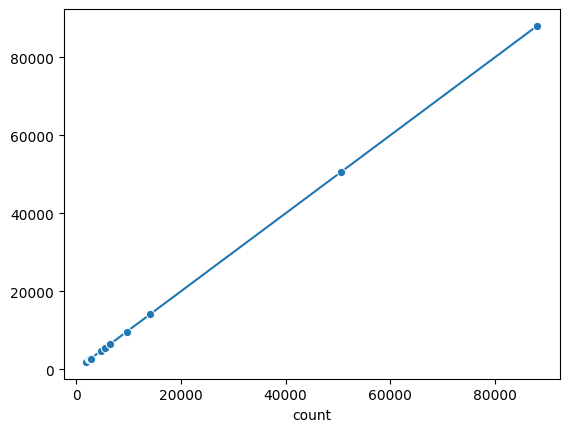

In [353]:
sns.lineplot(x=month_count,y=month_count.values,marker='o')

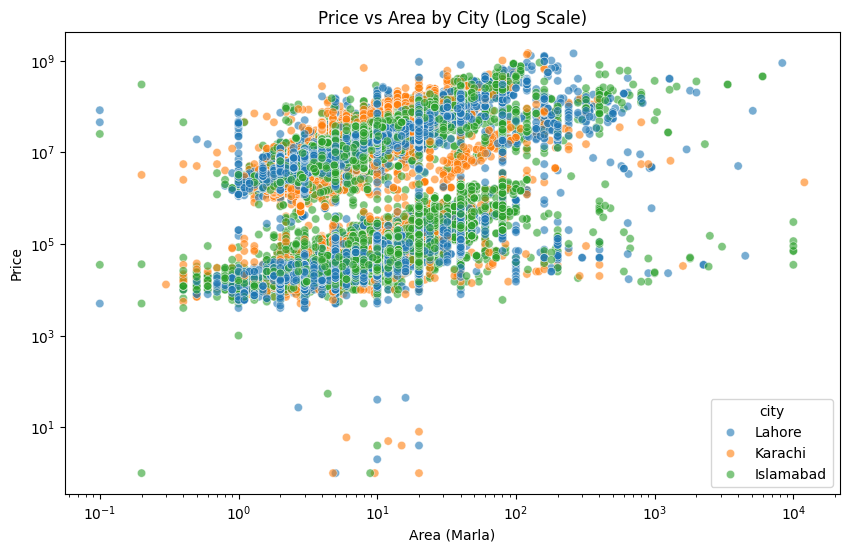

In [357]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df[df['city'].isin(['Lahore', 'Karachi', 'Islamabad'])],
    x='area_in_marla',
    y='price',
    hue='city',
    alpha=0.6
)

plt.xscale('log')
plt.yscale('log')

plt.title("Price vs Area by City (Log Scale)")
plt.xlabel("Area (Marla)")
plt.ylabel("Price")
plt.show()

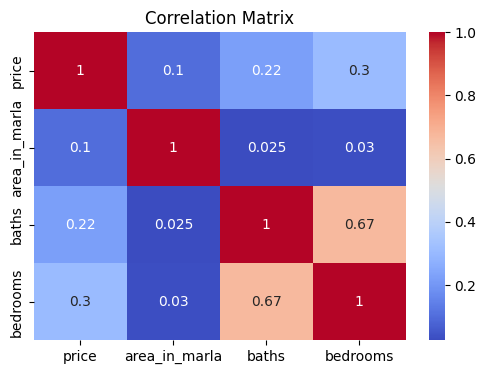

In [358]:
corr = df[['price','area_in_marla','baths','bedrooms']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

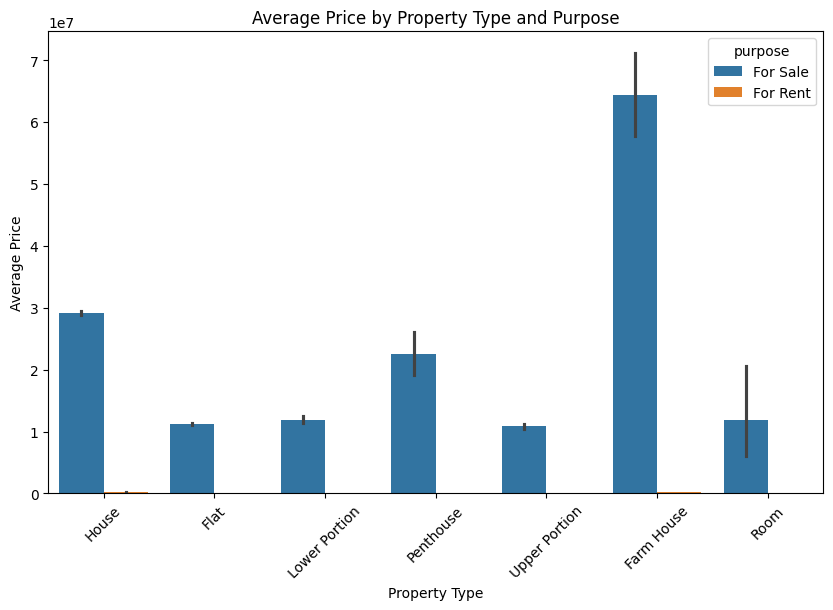

In [359]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='property_type',
    y='price',
    hue='purpose'
)

plt.title("Average Price by Property Type and Purpose")
plt.xlabel("Property Type")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

In [363]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year'] = df['date_added'].dt.year

threshold = df['price'].quantile(0.90)   # top 10% expensive properties

high_value = df[df['price'] > threshold]

city_year_growth = high_value.groupby(['year', 'city']).size().reset_index(name='count')
city_year_growth

,year,city,count
0,2018,Faisalabad,15
1,2018,Islamabad,165
2,2018,Karachi,395
3,2018,Lahore,221
4,2018,Rawalpindi,54
5,2019,Faisalabad,219
6,2019,Islamabad,3483
7,2019,Karachi,6684
8,2019,Lahore,7267
9,2019,Rawalpindi,553


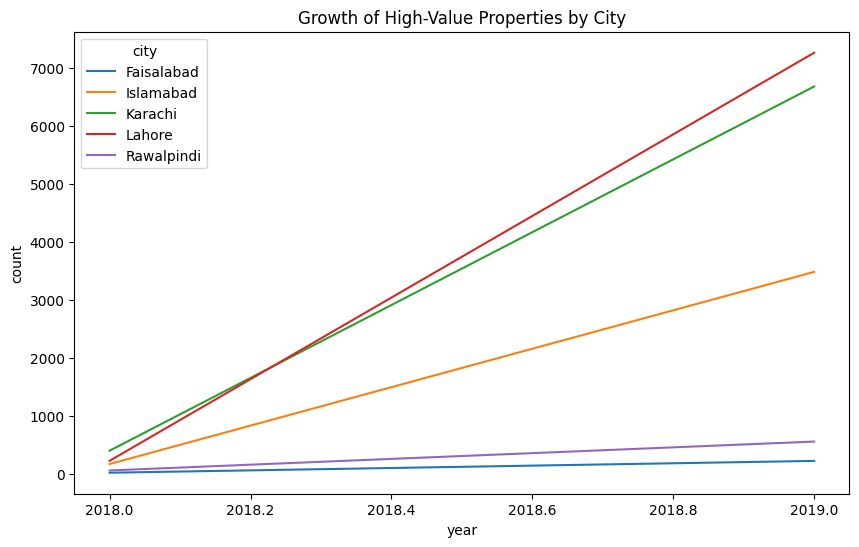

In [362]:
plt.figure(figsize=(10,6))
sns.lineplot(data=city_year_growth, x='year', y='count', hue='city')
plt.title("Growth of High-Value Properties by City")
plt.show()

In [364]:
city_type_year = df.groupby(['city', 'year', 'property_type']).size().reset_index(name='count')

In [365]:
city_type = df.groupby(['city', 'property_type']).size().reset_index(name='count')
city_type.sort_values(['city', 'count'], ascending=[True, False]).head(20)

,city,property_type,count
2,Faisalabad,House,7645
6,Faisalabad,Upper Portion,831
3,Faisalabad,Lower Portion,452
5,Faisalabad,Room,99
1,Faisalabad,Flat,46
0,Faisalabad,Farm House,5
4,Faisalabad,Penthouse,2
9,Islamabad,House,21276
8,Islamabad,Flat,7513
13,Islamabad,Upper Portion,5984


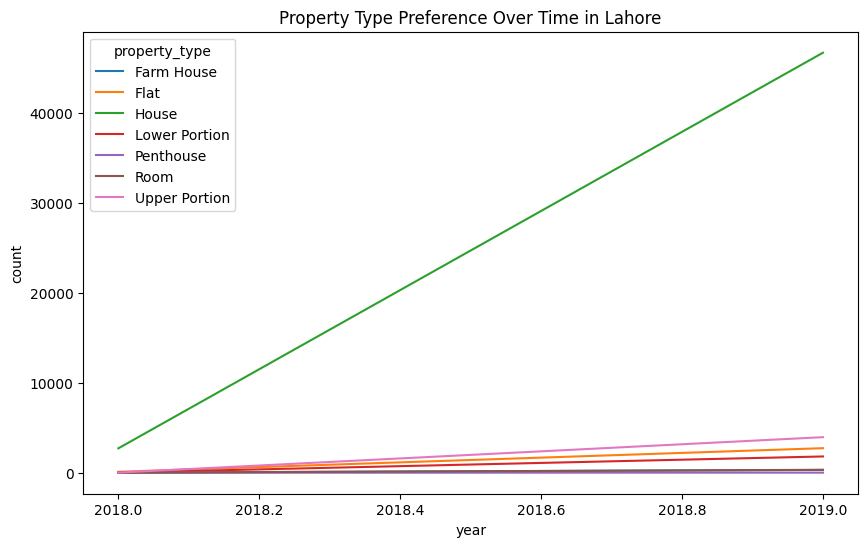

In [366]:
lahore_data = city_type_year[city_type_year['city'] == 'Lahore']

plt.figure(figsize=(10,6))
sns.lineplot(data=lahore_data, x='year', y='count', hue='property_type')
plt.title("Property Type Preference Over Time in Lahore")
plt.show()

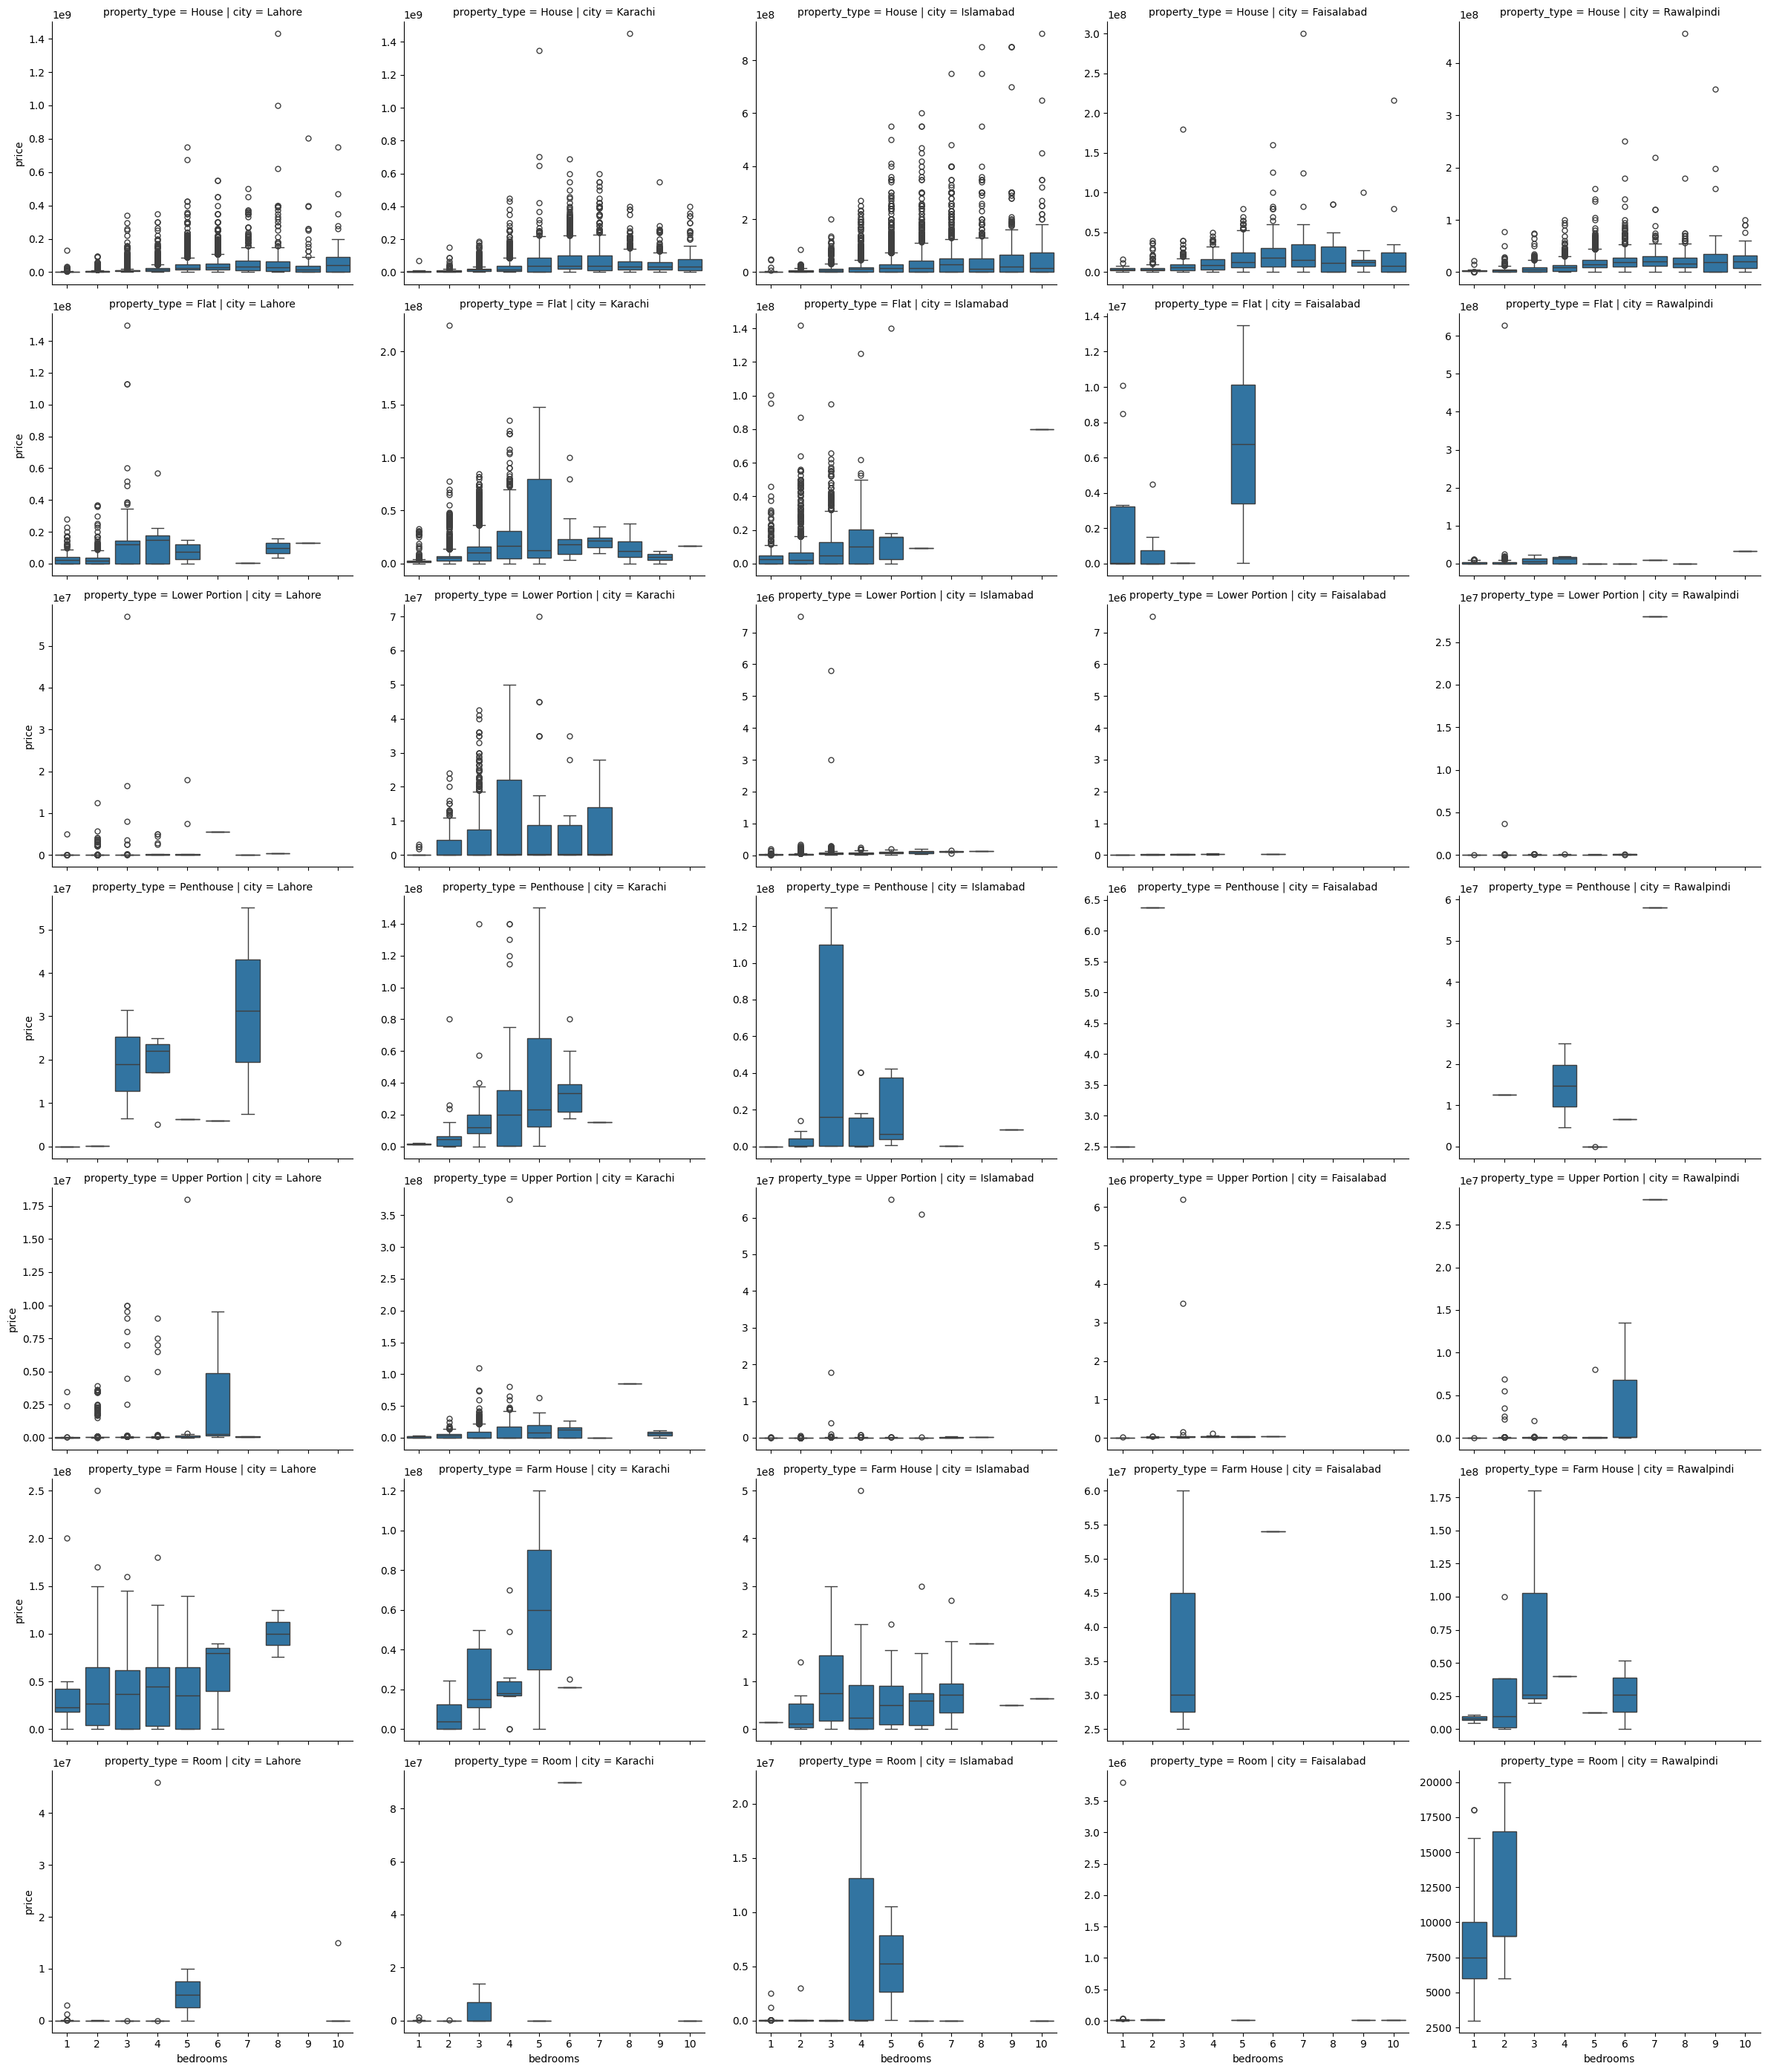

In [367]:
df_filtered = df[df['bedrooms'].between(1, 10)]

g = sns.catplot(
    data=df_filtered,
    x='bedrooms',
    y='price',
    col='city',
    row='property_type',
    kind='box',
    height=4,
    aspect=1.2,
    sharey=False
)

3. How do property prices vary with the number of bedrooms across different cities and property types?

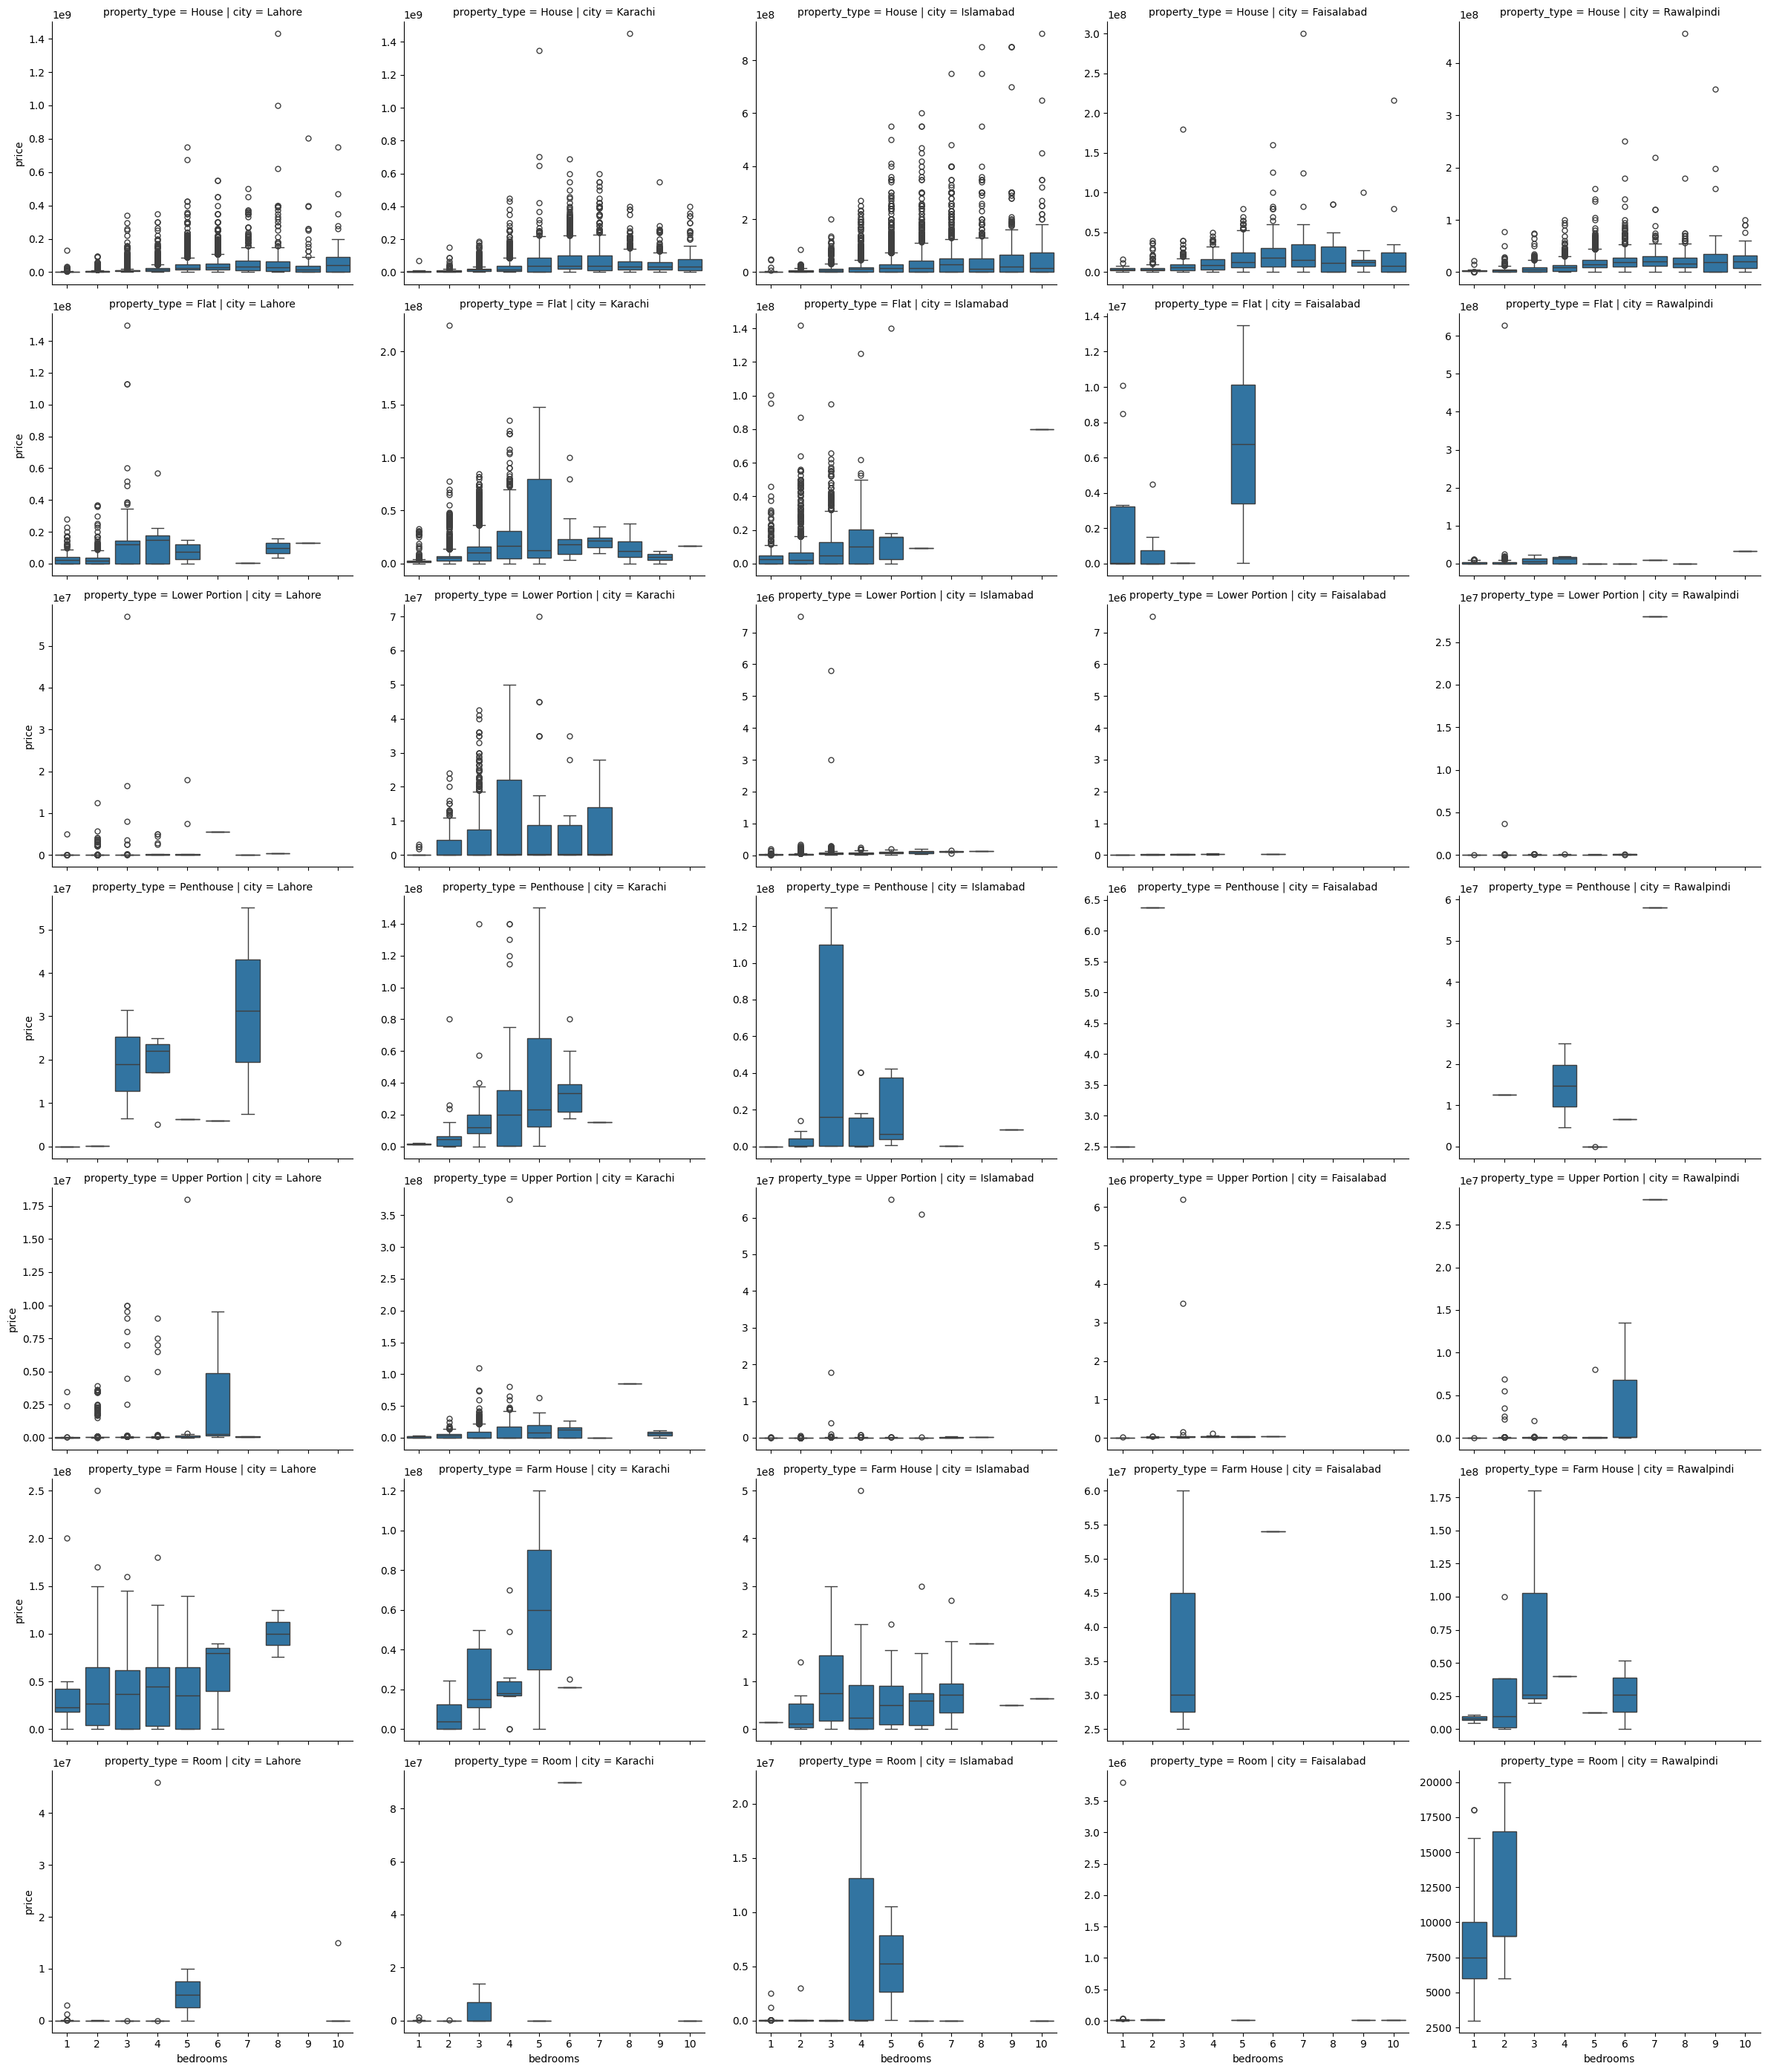

In [370]:
df_filtered = df[df['bedrooms'].between(1, 10)]

g = sns.catplot(
    data=df_filtered,
    x='bedrooms',
    y='price',
    col='city',
    row='property_type',
    kind='box',
    height=4,
    aspect=1.2,
    sharey=False
)

In [371]:
4. Which agencies have the most listings in high-demand areas?

Object `areas` not found.


In [374]:
top_locations = df['location'].value_counts().head(10).index

agency_high_demand = (
    df[df['location'].isin(top_locations)]
    .groupby('agency')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

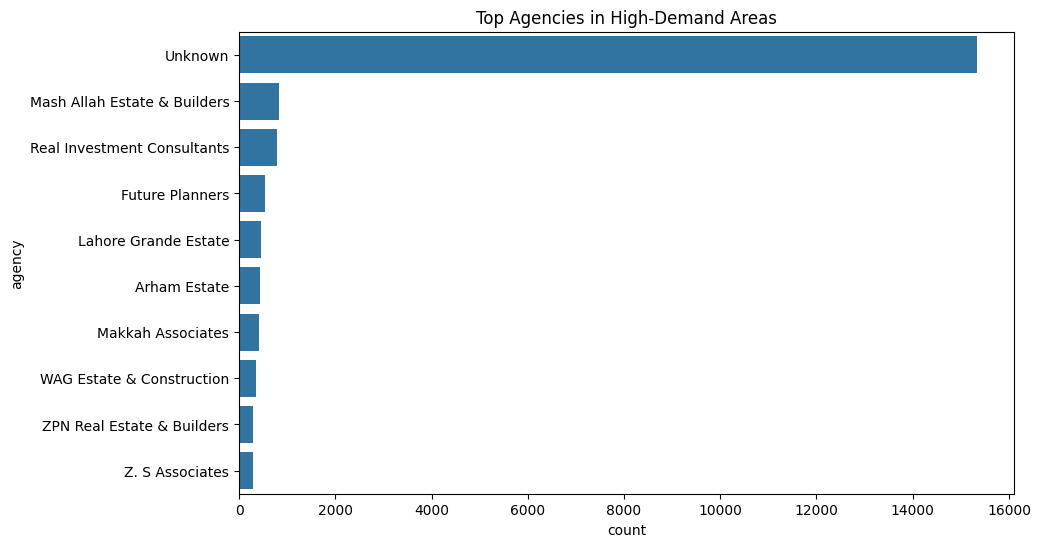

In [375]:
plt.figure(figsize=(10,6))
sns.barplot(data=agency_high_demand.head(10), x='count', y='agency')
plt.title("Top Agencies in High-Demand Areas")
plt.show()

In [376]:
5. Is there a seasonal trend in property listings?

Object `listings` not found.


In [377]:
df['month'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()

month_counts = df.groupby(['month', 'month_name']).size().reset_index(name='count').sort_values('month')

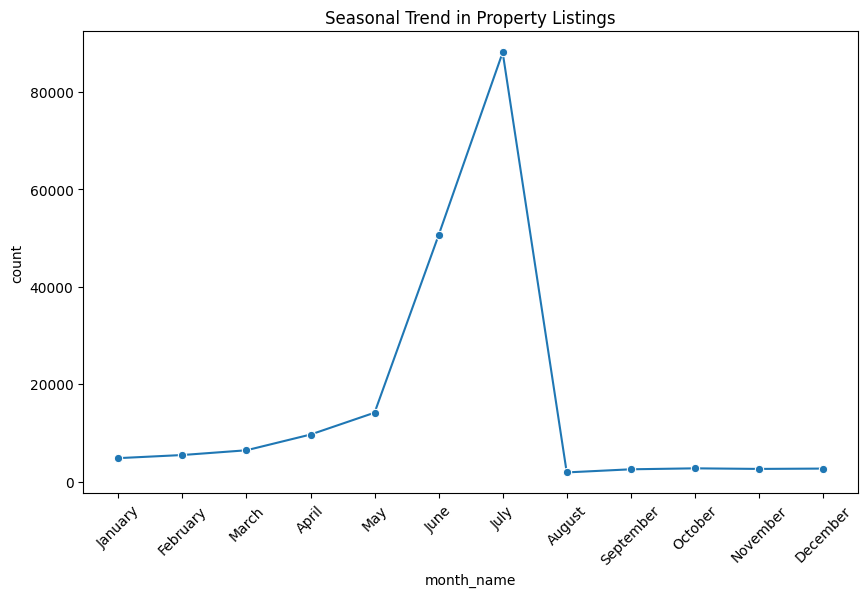

In [378]:
plt.figure(figsize=(10,6))
sns.lineplot(data=month_counts, x='month_name', y='count', marker='o')
plt.xticks(rotation=45)
plt.title("Seasonal Trend in Property Listings")
plt.show()

In [379]:
6. How do property sizes correlate with prices across different cities and property types?

Object `types` not found.


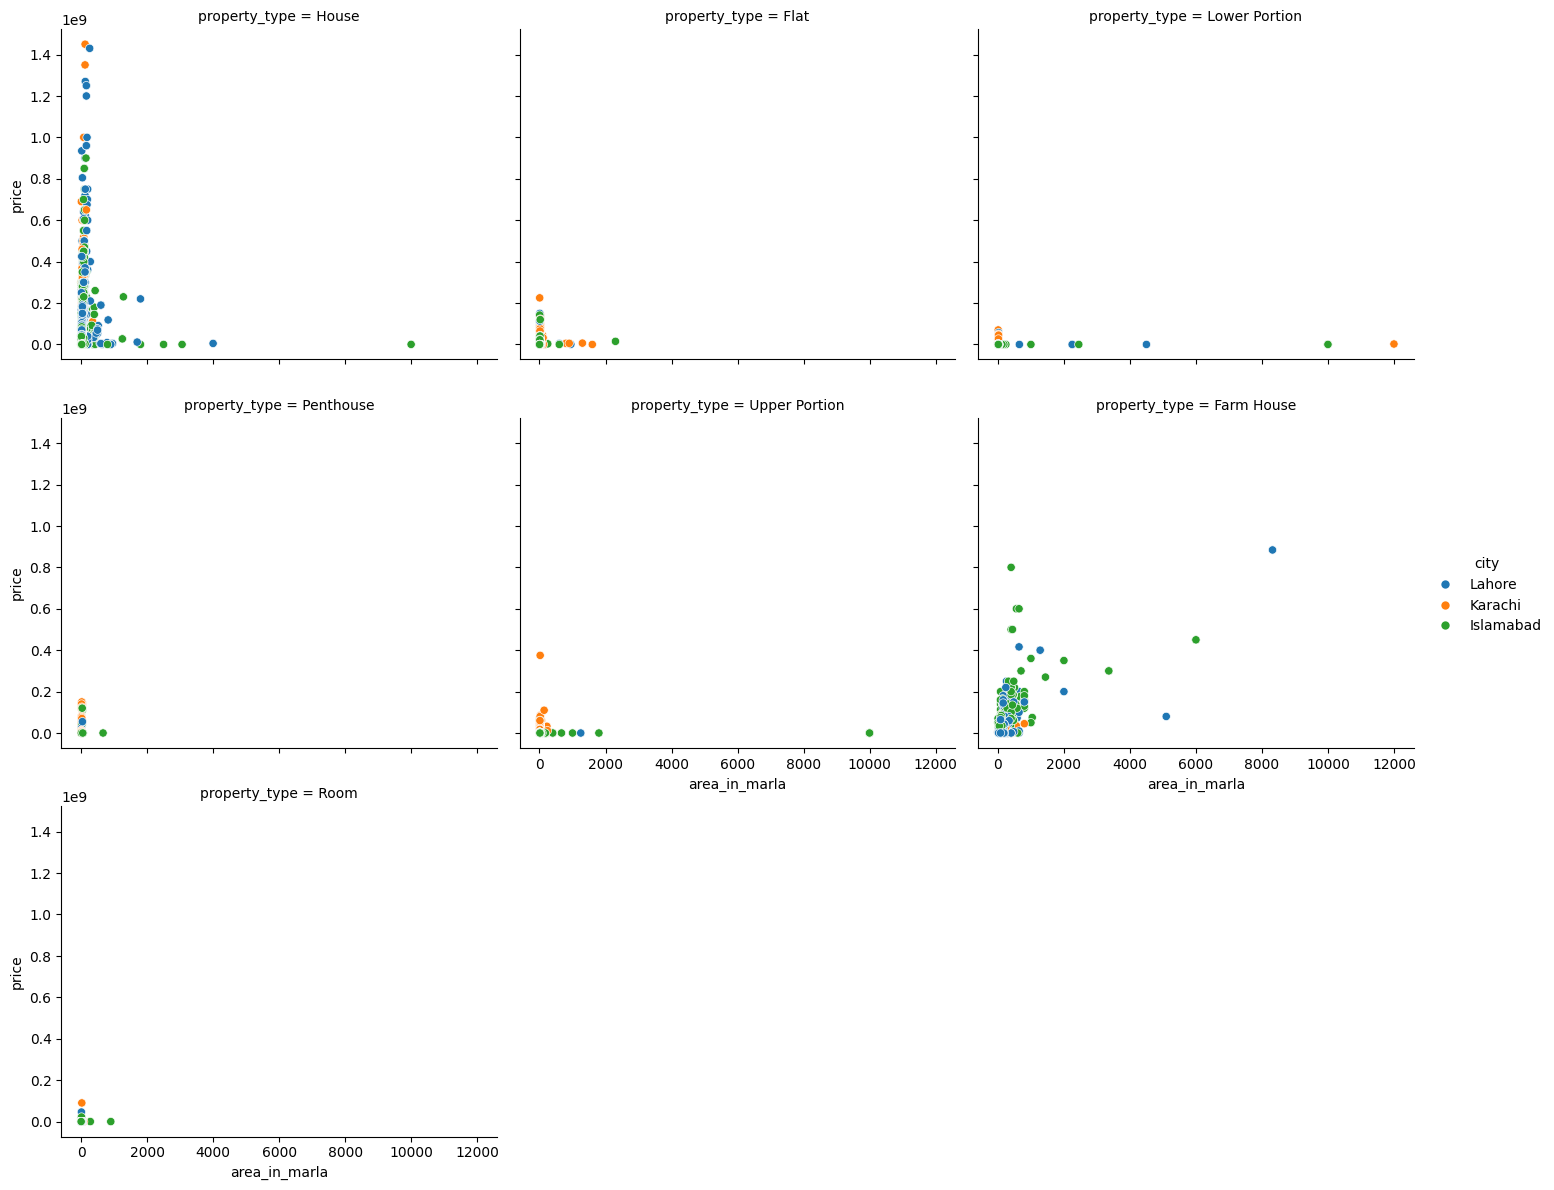

In [380]:
df_plot = df[
    (df['area_in_marla'] > 0) &
    (df['price'] > 0) &
    (df['city'].isin(['Lahore','Karachi','Islamabad']))
]

sns.relplot(
    data=df_plot,
    x='area_in_marla',
    y='price',
    hue='city',
    col='property_type',
    kind='scatter',
    col_wrap=3,
    height=4,
    aspect=1.2
)

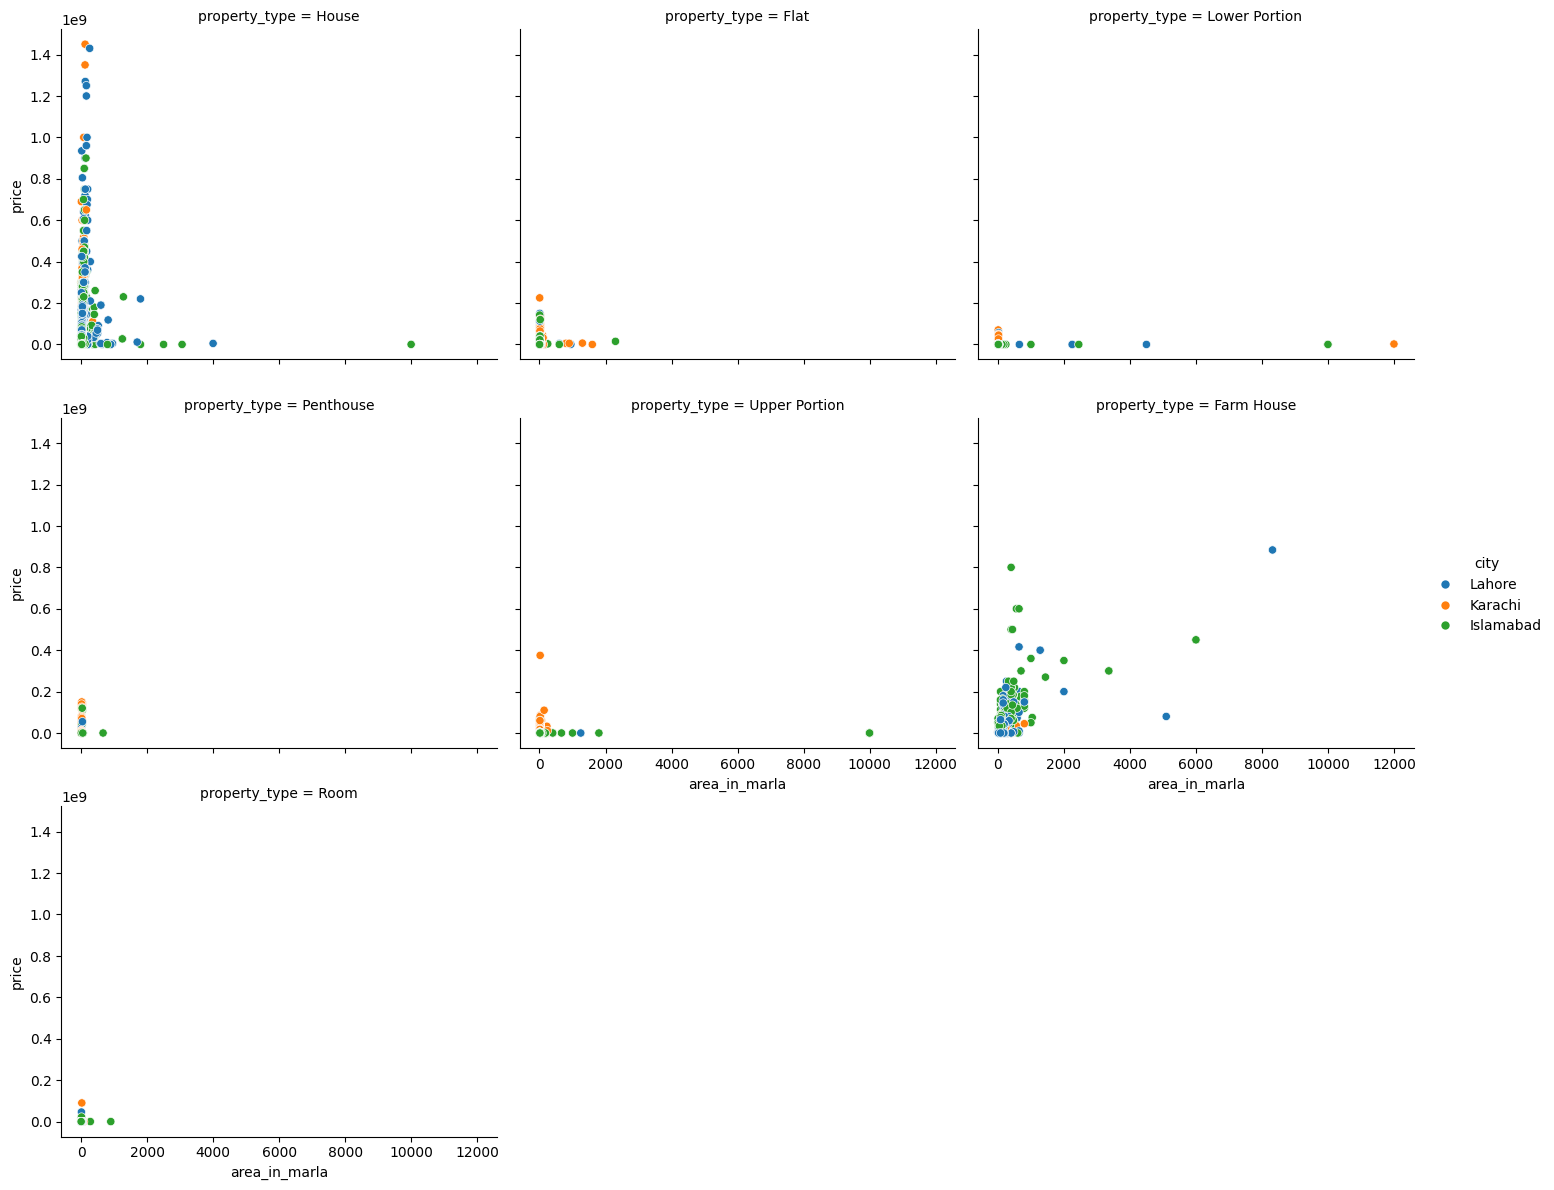

In [381]:
df_plot = df[
    (df['area_in_marla'] > 0) &
    (df['price'] > 0) &
    (df['city'].isin(['Lahore','Karachi','Islamabad']))
]

sns.relplot(
    data=df_plot,
    x='area_in_marla',
    y='price',
    hue='city',
    col='property_type',
    kind='scatter',
    col_wrap=3,
    height=4,
    aspect=1.2
)

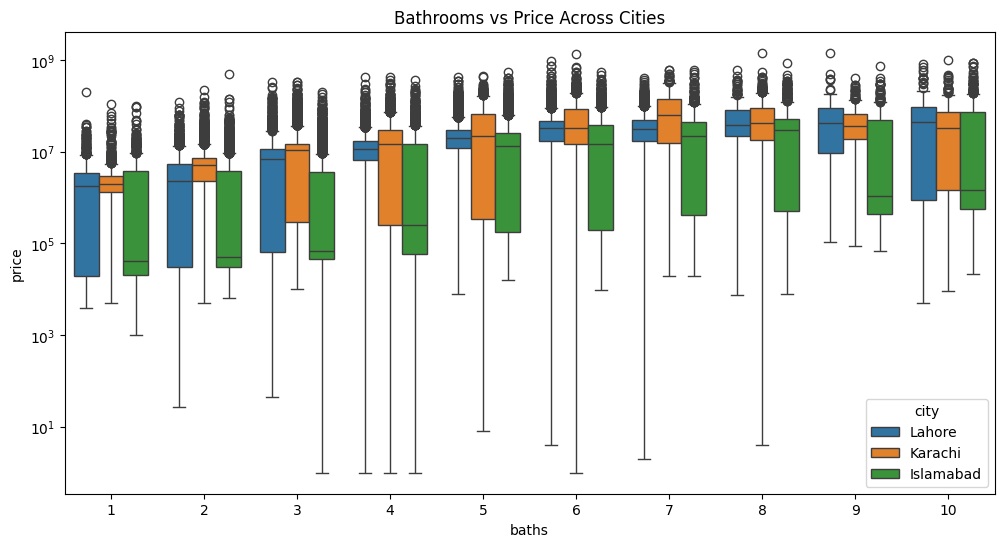

In [382]:
df_bath = df[df['baths'].between(1, 10) & df['city'].isin(['Lahore','Karachi','Islamabad'])]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_bath, x='baths', y='price', hue='city')
plt.yscale('log')
plt.title("Bathrooms vs Price Across Cities")
plt.show()

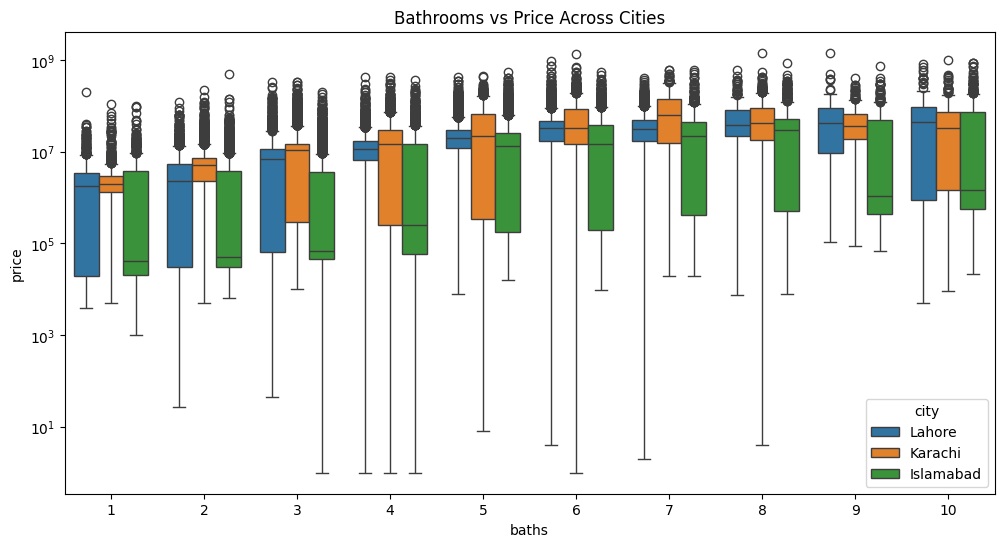

In [383]:
df_bath = df[df['baths'].between(1, 10) & df['city'].isin(['Lahore','Karachi','Islamabad'])]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_bath, x='baths', y='price', hue='city')
plt.yscale('log')
plt.title("Bathrooms vs Price Across Cities")
plt.show()

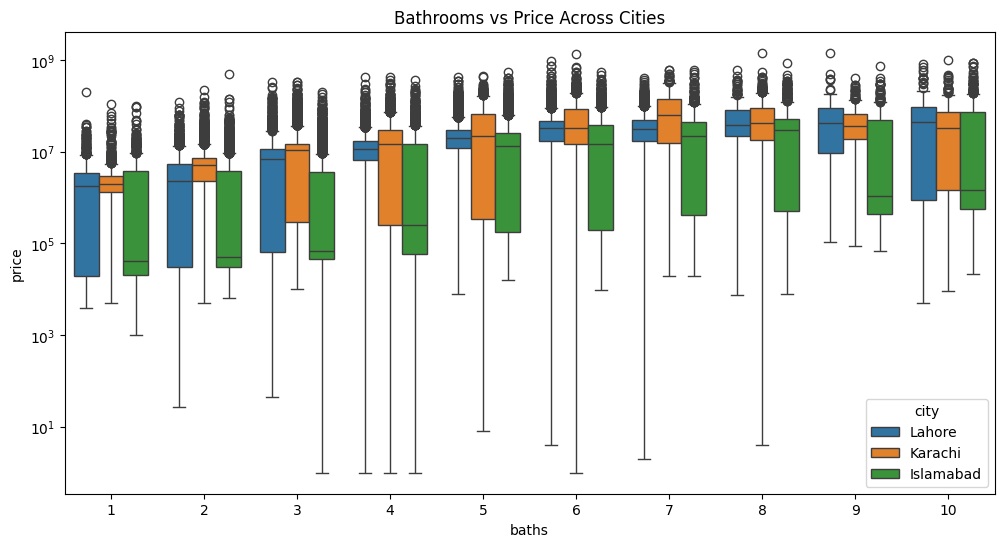

In [384]:
df_bath = df[df['baths'].between(1, 10) & df['city'].isin(['Lahore','Karachi','Islamabad'])]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_bath, x='baths', y='price', hue='city')
plt.yscale('log')
plt.title("Bathrooms vs Price Across Cities")
plt.show()

In [387]:
threshold = df['price'].quantile(0.90)
high_value = df[df['price'] > threshold]

top_agents = (
    high_value.groupby('agent')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

In [389]:
agent_city = (
    high_value.groupby(['agent', 'city'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)